# **News Category**

---

News headline categorization with fine-tuned DistilBERT, BiLSTM, Logistic Regression, and Naive Bayes.

## **DistilBERT**

---

Fine-tunes a pretrained DistilBERT classifier across the field configurations, scoring each on the held-out test split.

Outputs (under `results/distilbert/`):

- `scores.json`: test metrics per field configuration

- `best_params.json`: fixed model and training settings

### **Setup**

---

#### **Config**


In [1]:
import json
from pathlib import Path

import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import Dataset
from transformers import (
  AutoTokenizer,
  AutoModelForSequenceClassification,
  DataCollatorWithPadding,
  Trainer,
  TrainerCallback,
  TrainingArguments,
  EarlyStoppingCallback,
)
from IPython.display import clear_output
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

from news_category.data import load_split, assemble_fields, CONFIGS
from news_category.display import show
from news_category.evaluate import evaluate
from news_category.plotting import plot_confusion_matrix, plot_per_class_f1, plot_training_history, plot_metric_comparison

DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
VERSION = "v1"
CHECKPOINT = "distilbert-base-uncased"
RANDOM_STATE = 42

torch.manual_seed(RANDOM_STATE)
sns.set_theme(context="notebook", style="whitegrid")
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["figure.titleweight"] = "bold"
plt.rcParams["figure.titlesize"] = 18

#### **Load**


In [2]:
(df_train, df_test), labels = load_split(VERSION)
encoder = LabelEncoder().fit(labels)
tokenizer = AutoTokenizer.from_pretrained(CHECKPOINT)
show("Split Shapes", pd.DataFrame([df_train.shape, df_test.shape], index=["train", "test"], columns=["rows", "columns"]))

── Split Shapes ────────────────────────────


,rows,columns
train,167218,6
test,41805,6


#### **Token Lengths**

Measure the tokenized length of each configuration's assembled text to confirm the truncation limit keeps almost every example intact.


In [3]:
lengths = {
  config: assemble_fields(df_train, config)
  .map(lambda text: len(tokenizer(text)["input_ids"]))
  .describe(percentiles=[0.95, 0.99])
  for config in CONFIGS
}
show("Token Lengths", pd.DataFrame(lengths).round().astype(int))

── Token Lengths ───────────────────────────


,headline,short_description,authors,headline+short_description,headline+authors,short_description+authors,headline+short_description+authors
count,167218,167218,167218,167218,167218,167218,167218
mean,15,27,9,41,23,35,49
std,5,17,7,17,7,22,21
min,2,2,2,4,4,3,5
50%,14,26,6,39,21,30,45
95%,22,60,25,72,37,78,90
99%,26,73,29,87,44,93,106
max,130,350,46,354,131,356,360


### **Training**

---

For each field configuration, assemble the input text and tune the pipeline over the shared folds, scoring on the test split. The author-only configuration drops blank-author rows so it measures author signal fairly; the other configurations keep every row.

#### **Model**

The fine-tuning settings shared by every configuration, and a factory that loads a fresh pretrained classifier weighted against class imbalance.


In [4]:
MAX_LENGTH = 128
BATCH_SIZE = 64
MAX_EPOCHS = 12
PATIENCE = 3
LEARNING_RATE = 5e-5

HYPERPARAMS = {
  "checkpoint": CHECKPOINT,
  "max_length": MAX_LENGTH,
  "batch_size": BATCH_SIZE,
  "max_epochs": MAX_EPOCHS,
  "patience": PATIENCE,
  "learning_rate": LEARNING_RATE,
}


class WeightedTrainer(Trainer):
  def __init__(self, weights: torch.Tensor, **kwargs):
    super().__init__(**kwargs)
    self.weights = weights.to(self.args.device)

  def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
    labels = inputs.pop("labels")
    outputs = model(**inputs)
    loss = torch.nn.functional.cross_entropy(outputs.logits, labels, weight=self.weights)
    return (loss, outputs) if return_outputs else loss

#### **Helpers**

Tokenize the assembled text, record train and validation macro-F1 each epoch, and score a dataset on the best epoch.


In [5]:
def tokenize(texts: pd.Series, y: np.ndarray) -> Dataset:
  dataset = Dataset.from_dict({"text": texts.tolist(), "labels": y})
  return dataset.map(lambda batch: tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH), batched=True)


def compute_metrics(prediction) -> dict:
  y_pred = prediction.predictions.argmax(axis=1)
  return {"f1": evaluate(prediction.label_ids, y_pred)["f1"]}


class MetricsHistory(TrainerCallback):
  def __init__(self, trainer: Trainer, train_dataset: Dataset):
    self.trainer = trainer
    self.train_dataset = train_dataset
    self.history = {"train": [], "validation": []}

  def on_evaluate(self, args, state, control, metrics, **kwargs):
    train_f1 = self.trainer.predict(self.train_dataset, metric_key_prefix="train").metrics["train_f1"]
    self.history["train"].append(train_f1)
    self.history["validation"].append(metrics["eval_f1"])

#### **Per-Field Training**

Fine-tune the model for each field configuration and score the best epoch on the test split; the author-only configuration uses just the author-present rows.


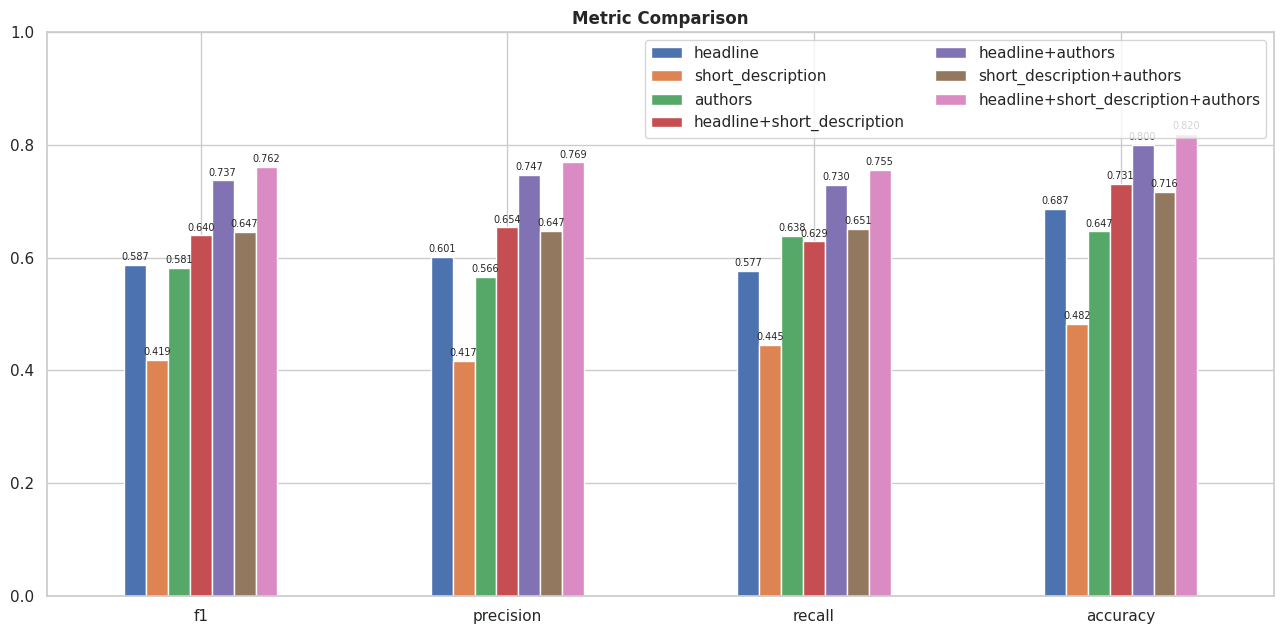

In [6]:
results = {}
predictions = {}
histories = {}
tests = {}
collator = DataCollatorWithPadding(tokenizer)

for config in CONFIGS:
  train_mask = df_train["has_author"] if config == "authors" else pd.Series(True, index=df_train.index)
  test_mask = df_test["has_author"] if config == "authors" else pd.Series(True, index=df_test.index)

  y_train = encoder.transform(df_train[train_mask]["category"])
  y_test = encoder.transform(df_test[test_mask]["category"])
  weights = torch.tensor(compute_class_weight("balanced", classes=np.arange(len(labels)), y=y_train), dtype=torch.float32)

  text_train = assemble_fields(df_train[train_mask], config)
  text_fit, text_val, y_fit, y_val = train_test_split(
    text_train, y_train, test_size=0.1, stratify=y_train, random_state=RANDOM_STATE
  )
  fit = tokenize(text_fit, y_fit)
  val = tokenize(text_val, y_val)
  test = tokenize(assemble_fields(df_test[test_mask], config), y_test)

  show(config)
  args = TrainingArguments(
    output_dir=f"checkpoints/distilbert/{config}",
    eval_strategy="epoch",
    save_strategy="epoch",
    num_train_epochs=MAX_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    save_total_limit=1,
    seed=RANDOM_STATE,
    report_to="none",
    disable_tqdm=True,
    dataloader_pin_memory=(DEVICE == "cuda"),
  )
  model = AutoModelForSequenceClassification.from_pretrained(CHECKPOINT, num_labels=len(labels))
  trainer = WeightedTrainer(
    weights=weights,
    model=model,
    args=args,
    train_dataset=fit,
    eval_dataset=val,
    data_collator=collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=PATIENCE)],
  )
  monitor = MetricsHistory(trainer, fit)
  trainer.add_callback(monitor)
  trainer.train()

  y_pred = trainer.predict(test).predictions.argmax(axis=1)
  results[config] = evaluate(y_test, y_pred)
  predictions[config] = encoder.inverse_transform(y_pred)
  histories[config] = monitor.history
  tests[config] = encoder.inverse_transform(y_test)
  clear_output(wait=True)

fig, ax = plt.subplots(figsize=(13, 6.5))
plot_metric_comparison(results, ax=ax)
plt.tight_layout()
plt.show()

### **Diagnostics**

---

#### **Field Strengths & Weaknesses**

Three plots reveal what each configuration does well and poorly:

- **Confusion matrix**: which categories get mistaken for each other.

- **Per-class F1**: which categories the model handles worst.

- **Training history**: whether the model overfits as epochs progress..


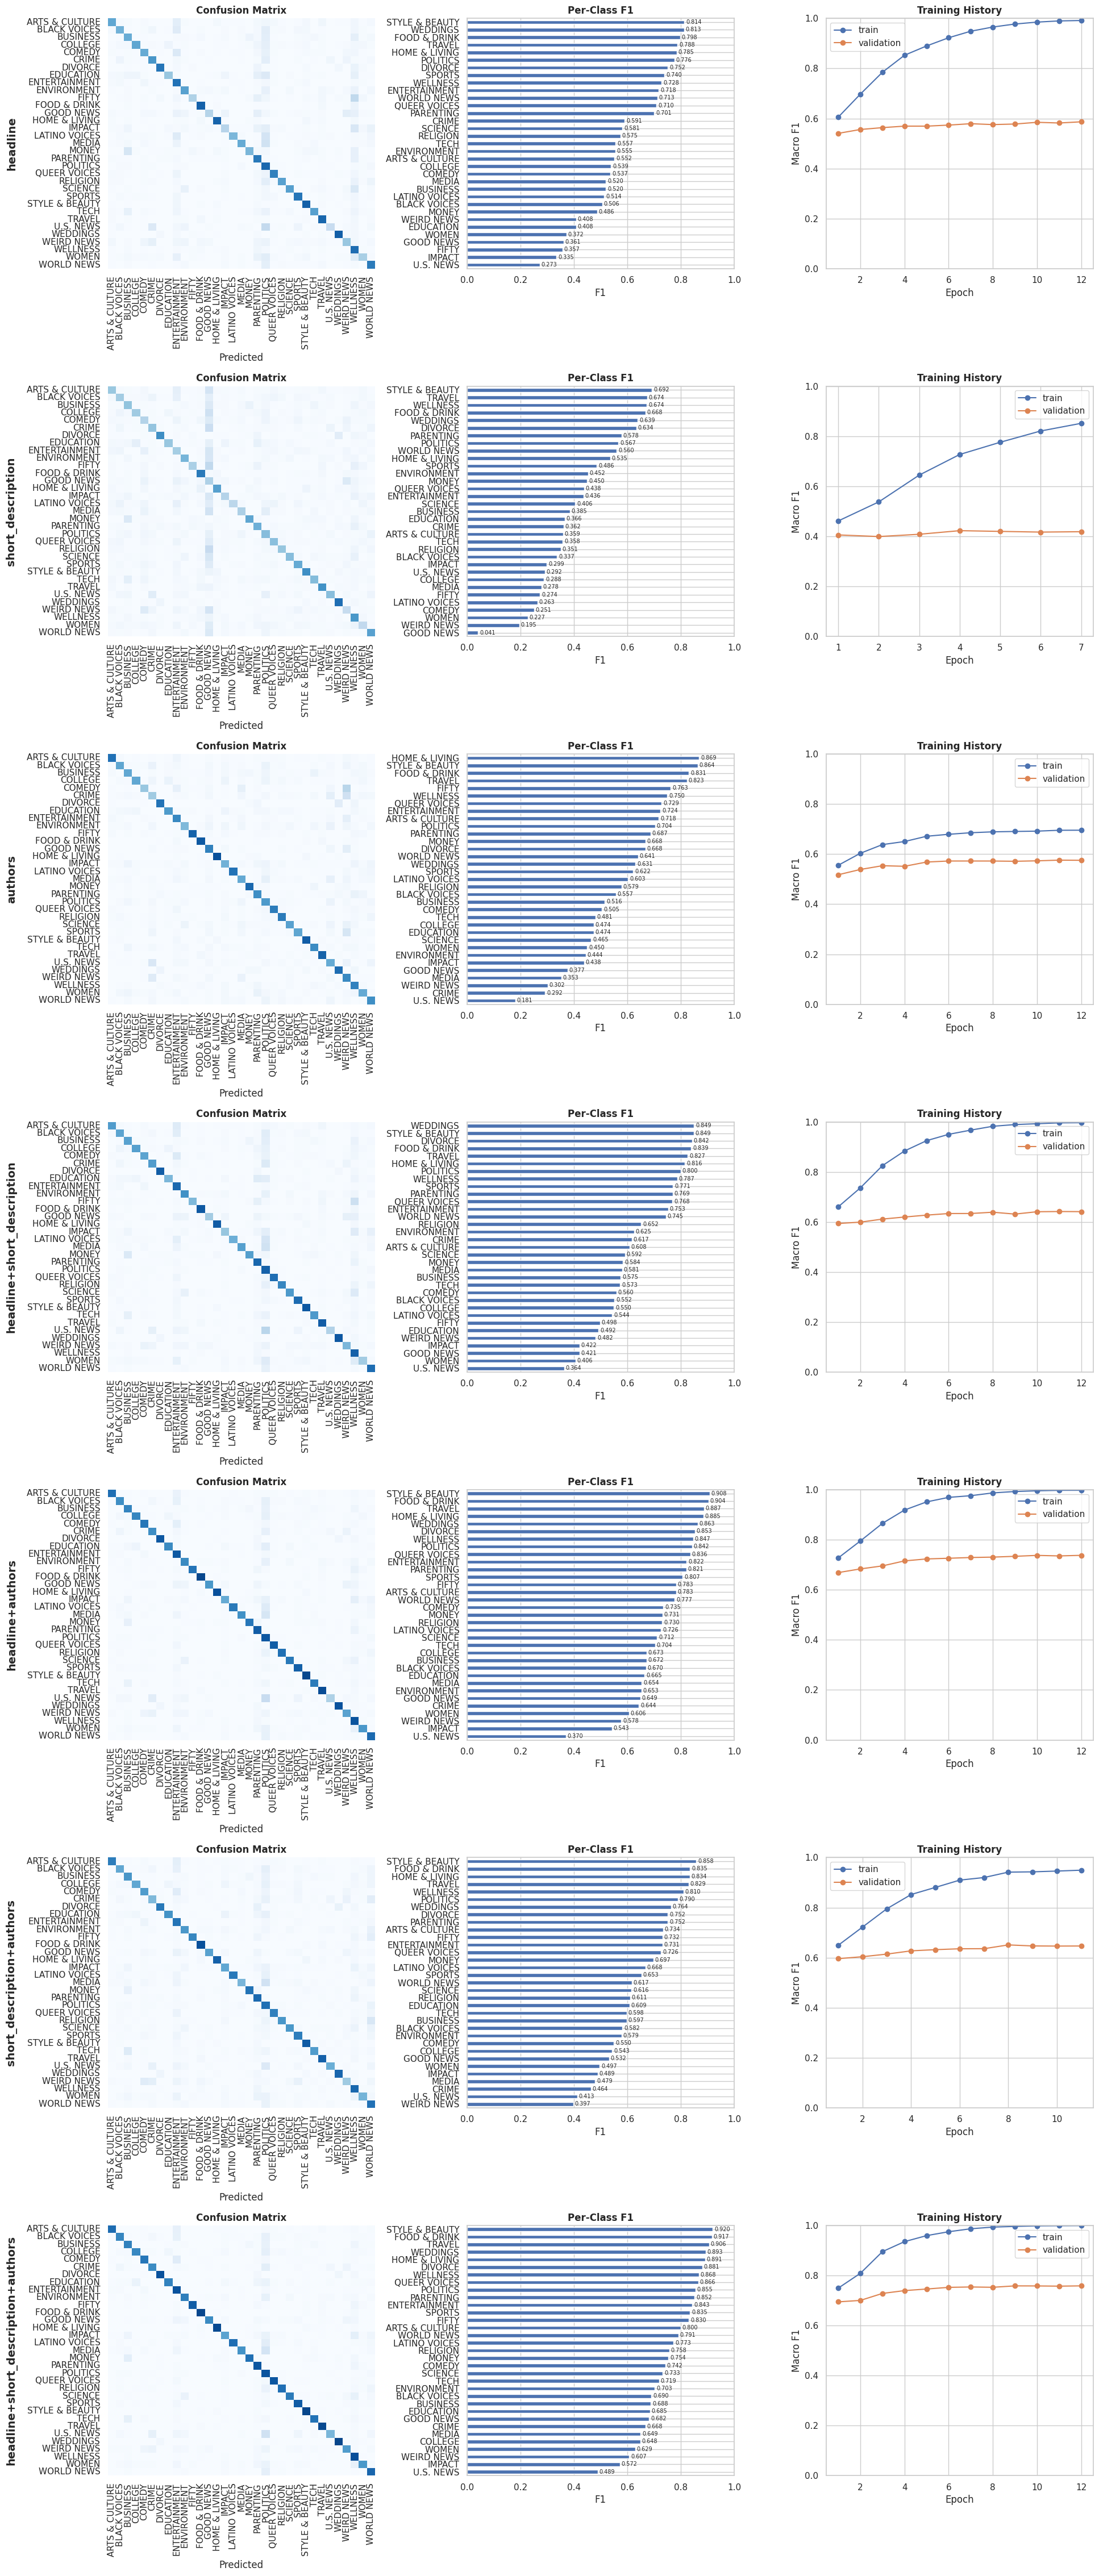

In [7]:
fig, axes = plt.subplots(len(CONFIGS), 3, figsize=(3 * 6.5, len(CONFIGS) * 6.5))
for row, config in zip(axes, CONFIGS):
  plot_confusion_matrix(tests[config], predictions[config], labels, ax=row[0])
  plot_per_class_f1(tests[config], predictions[config], labels, ax=row[1])
  plot_training_history(histories[config], ax=row[2])
  row[0].set_ylabel(config, fontsize=14, fontweight="bold", labelpad=12)
plt.tight_layout()
plt.show()

#### **Best Hyperparameters**

The fixed model and training settings behind every configuration's score.


In [8]:
show("Hyperparameters", pd.Series(HYPERPARAMS).to_frame("value"))

── Hyperparameters ─────────────────────────


,value
checkpoint,distilbert-base-uncased
max_length,128
batch_size,64
max_epochs,12
patience,3
learning_rate,0.00005


### **Output**

---

Write the per-configuration test scores and winning hyperparameters, for the comparison notebook.


In [9]:
DIR_OUT = Path("results/distilbert")
DIR_OUT.mkdir(parents=True, exist_ok=True)
with open(DIR_OUT / "scores.json", "w") as f:
  json.dump(results, f, indent=2)
with open(DIR_OUT / "best_params.json", "w") as f:
  json.dump({config: HYPERPARAMS for config in CONFIGS}, f, indent=2)
show("Saved", str(DIR_OUT))

── Saved ───────────────────────────────────
results/distilbert
